<a href="https://colab.research.google.com/github/anjicx/CNHypergraph/blob/main/FirstScript.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading the data

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [19]:
diagnosis = pd.read_csv("data/table_diagnoses.csv", sep=";")
stays = pd.read_csv("data/final_one_percent_stays.csv", sep=";")
stays_secondaries = pd.read_csv("data/final_one_percent_stays_secondaries.csv", sep=";")
age = pd.read_csv("data/table_age.csv", sep=";", encoding="latin1")
#merging data
stays = stays.merge(age, on="ag_id", how="left")
stays = stays.rename(columns={"age": "age_group"})

Taking into account :

1.ICD CODE SYSTEM CHANGES 2002 and taking only A-N diagnosis
2.PATIENTS CHANGING AGE GROUPS-1st diagnosis age group
3.MORE THEN 20 YEARS OLD, ENOUGH TRAJECTORIES

1. Only patients who were healthy from 2003 are kept (all patients who had at least a stay before 2003 are removed)

In [20]:
WASHOUT_END   = pd.Timestamp("2002-12-31")
OBS_START = pd.Timestamp("2003-01-01")

stays["entry_date"] = pd.to_datetime(stays["entry_date"], errors="coerce")

# numbers before filtering
n_patients_before = stays["patient_no"].nunique()
n_stays_before = stays.shape[0]

# patients with AT LEAST ONE stay in washout period 1997-2002
patients_pre_2003 = stays.loc[
    (stays["entry_date"] <= WASHOUT_END),
    "patient_no"
].dropna().unique()

# remove these patients completely
stays_after_washout = stays[
    ~stays["patient_no"].isin(patients_pre_2003)
].copy()

# keep only observation period from 2003
stays_obs = stays_after_washout[(stays_after_washout["entry_date"] >= OBS_START) ].copy()


In [21]:
# patient cohort summary table
cohort_summary = pd.DataFrame([
    {
        "step": "Before filtering",
        "n_patients": n_patients_before,
        "n_stays": n_stays_before,
        "description": "All available patients and stays before applying washout filter"
    },
    {
        "step": "After removing pre-2003 patients",
        "n_patients": stays_after_washout["patient_no"].nunique(),
        "n_stays": stays_after_washout.shape[0],
        "description": "Patients with any stay before 2003 were removed completely"
    },
    {
        "step": "Observation period from 2003",
        "n_patients": stays_obs["patient_no"].nunique(),
        "n_stays": stays_obs.shape[0],
        "description": "Final dataset restricted to stays from 2003 onward"
    }
])
cohort_summary.to_csv("cohort_summary.csv", index=False)

In [22]:
# creating stays related to every patient
patient_stays = stays_obs[["patient_no", "entry_date", "exit_date", "sex_id", "age_group"]].copy()
patient_stays = patient_stays[patient_stays["sex_id"].isin([1, 2])].copy()
patient_stays["entry_date"] = pd.to_datetime(patient_stays["entry_date"])
patient_stays["exit_date"] = pd.to_datetime(patient_stays["exit_date"])
patient_stays = patient_stays.sort_values(["patient_no", "entry_date"])#patient stays sorted by entry date
#just takes the year from the entry date
patient_stays["year"] = patient_stays["entry_date"].dt.year

#COUNTNING NUMBER OF UNIQUE YEARS IN VISITS OF EACH PATIENT
unique_years = (
    patient_stays.groupby("patient_no")["year"].nunique()# group by patient, count distinct years
    .reset_index(name="n_unique_years")
)

In [23]:
# assign age group and sex from the first visit
first_visit = patient_stays.drop_duplicates("patient_no", keep="first")[
    ["patient_no", "sex_id", "age_group"]
]

patient_filter = first_visit.merge(unique_years, on="patient_no", how="left")

patient_filter["sex"] = patient_filter["sex_id"].map({
    1: "Male",
    2: "Female"
})

2. Patients >= 20 years

In [24]:
patient_filter["age_group"] = patient_filter["age_group"].astype(str).str.strip()
patient_filter["age_start"] = (
    patient_filter["age_group"]
    .str.extract(r"(\d+)")
    .astype(float)
)# to extract the start age in the age group
patient_filter = patient_filter[patient_filter["age_start"] >= 20].copy()#filter 20+

In [25]:
#adding to summary table
age_filter_row = pd.DataFrame([
    {
        "step": "After age filter: age >= 20",
        "n_patients": patient_filter["patient_no"].nunique(),
        "n_stays": stays_obs[
            stays_obs["patient_no"].isin(patient_filter["patient_no"])
        ].shape[0],
        "description": "Patients retained after requiring first observed age group to be at least 20"
    }
])

cohort_summary = pd.concat(
    [cohort_summary, age_filter_row],
    ignore_index=True
)


3. NUMBER OF UNIQUE YEARS FOR THAT PATIENT >= 3

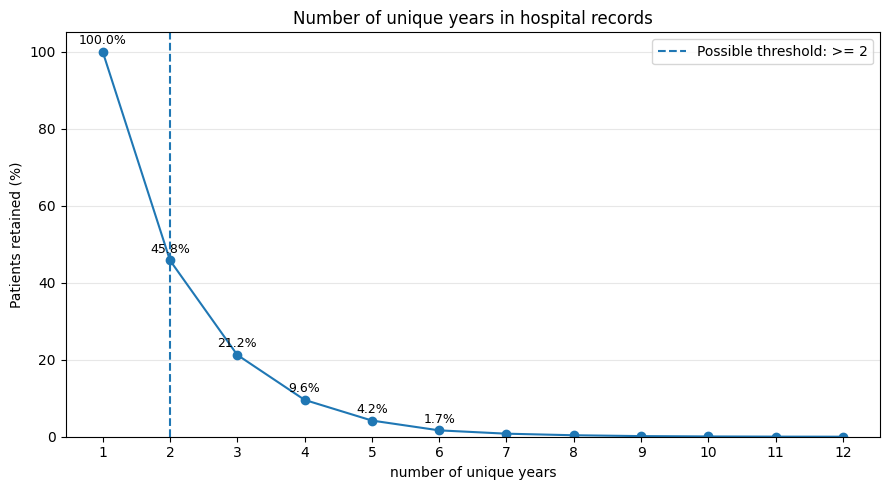

In [26]:
base_cohort = patient_filter.copy()

base_cohort["n_unique_years"] = pd.to_numeric(
    base_cohort["n_unique_years"],
    errors="coerce"
)

base_cohort = base_cohort.dropna(subset=["n_unique_years"]).copy()
base_cohort["n_unique_years"] = base_cohort["n_unique_years"].astype(int)

total_patients = base_cohort["patient_no"].nunique()

max_years = base_cohort["n_unique_years"].max()

retention_rows = []

for threshold in range(1, max_years + 1):
    n_patients = base_cohort.loc[
        base_cohort["n_unique_years"] >= threshold,
        "patient_no"
    ].nunique()
    
    retention_rows.append({
        "min_unique_years": threshold,
        "n_patients": n_patients,
        "percent_retained": 100 * n_patients / total_patients
    })

retention_df = pd.DataFrame(retention_rows)

retention_df.to_csv("unique_years_retention_curve.csv", index=False)

retention_df
plt.figure(figsize=(9, 5))

plt.plot(
    retention_df["min_unique_years"],
    retention_df["percent_retained"],
    marker="o"
)

plt.axvline(2, linestyle="--", label="Possible threshold: >= 2")

for _, row in retention_df.iterrows():
    if row["min_unique_years"] <= 6:
        plt.text(
            row["min_unique_years"],
            row["percent_retained"] + 2,
            f'{row["percent_retained"]:.1f}%',
            ha="center",
            fontsize=9
        )

plt.xlabel("number of unique years")
plt.ylabel("Patients retained (%)")
plt.title("Number of unique years in hospital records")
plt.xticks(retention_df["min_unique_years"])
plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("unique_yearsGraph1.png", dpi=150)
plt.show()

In [27]:
patient_filter = patient_filter[patient_filter["n_unique_years"] >= 2].copy()
#ALL THE PATIENTS THAT CAME THROUGH FILTER

unique_years_row = pd.DataFrame([
    {
        "step": "After unique years filter: n_unique_years >= 2",
        "n_patients": patient_filter["patient_no"].nunique(),
        "n_stays": stays_obs[
            stays_obs["patient_no"].isin(patient_filter["patient_no"])
        ].shape[0],
        "description": "Patients retained after requiring at least 2 unique observation years"
    }
])

cohort_summary = pd.concat(
    [cohort_summary, unique_years_row],
    ignore_index=True
)

# update removed and percent columns
cohort_summary["removed_from_previous"] = (
    cohort_summary["n_patients"].shift(1) - cohort_summary["n_patients"]
).fillna(0).astype(int)

cohort_summary["percent_remaining"] = (
    100 * cohort_summary["n_patients"] / cohort_summary.loc[0, "n_patients"]
).round(2)

# save updated table
cohort_summary.to_csv("cohort_summary.csv", index=False)


patient_filter is our cohort of patients -> filtering only the stays from our cohort

In [28]:
filtered_stays = stays_obs[stays_obs["patient_no"].isin(patient_filter["patient_no"])].copy()
filtered_stays["entry_date"] = pd.to_datetime(filtered_stays["entry_date"])
filtered_stays["exit_date"] = pd.to_datetime(filtered_stays["exit_date"], errors="coerce")

print("Filtered stays shape:", filtered_stays.shape)

Filtered stays shape: (125458, 13)


Creating a hypergraph

CREATING A DICTIONARY CONTAINING ALL DIAGNOSIS AND A TABLE OF STAYS.
EACH ROW IS ONE DIAGNOSIS CONNECTED TO STAY

In [29]:
# building nodes of diagnosis
diagnosis["icd_code"] = (diagnosis["icd_code"].astype(str).str.strip().str.upper().str.replace(".", "", regex=False))

diagnosis["diagnose_id"] = pd.to_numeric( diagnosis["diagnose_id"], errors="coerce")

nodes = diagnosis[
    diagnosis["icd_code"].str.match(r"^[A-N][0-9]{2}", na=False)
].copy()

nodes = nodes.dropna(subset=["diagnose_id"]).copy()
nodes["diagnose_id"] = nodes["diagnose_id"].astype(int)
nodes = nodes.drop_duplicates(subset=["diagnose_id"]).copy()
nodes["node_id"] = range(len(nodes))
nodes = nodes[["node_id", "diagnose_id", "descr", "icd_code"]].copy()

In [30]:
#creating a tbl of primary diagnosis
primary = filtered_stays[["stay_id", "patient_no", "entry_date", "pri_diag_id"]].copy()#stays has for key to diagnosis
primary = primary.rename(columns={"pri_diag_id": "diagnose_id"})#rename foreign key diagnose_id
primary["diagnose_id"] = pd.to_numeric(primary["diagnose_id"])
primary["role"] = "primary"

#creating a tbl of secondary diagnosis

filtered_stays_secondaries = stays_secondaries[stays_secondaries["stay_id"].isin(filtered_stays["stay_id"])].copy()
filtered_stays_secondaries["sec_diag_id"] = pd.to_numeric(filtered_stays_secondaries["sec_diag_id"])
secondary = filtered_stays_secondaries.merge(filtered_stays[["stay_id", "patient_no", "entry_date"]],on="stay_id",how="inner")
secondary = secondary.rename(columns={"sec_diag_id": "diagnose_id"})
secondary["role"] = "secondary"

In [31]:
# NODES TABLE: node id connected to diagnosis
stay_diagnoses = pd.concat([primary, secondary], ignore_index=True)
# remove rows with missing diagnosis ids
stay_diagnoses = stay_diagnoses.dropna(subset=["diagnose_id"]).copy()
# inner join
stay_diagnoses = pd.merge(stay_diagnoses,nodes,on="diagnose_id",how="inner")


For each patient keep only the first appearance of diagnosis.Then merge the whole data and sort so you can track which diagnosis was first.Afterwards divide by gender.

In [32]:
patient_first_diag = (stay_diagnoses.groupby(["patient_no", "node_id"], as_index=False)["entry_date"].min()
.rename(columns={"entry_date": "first_date"})
)
patient_first_diag = patient_first_diag.merge(
    nodes[["node_id", "diagnose_id", "descr", "icd_code"]].drop_duplicates(subset=["node_id"]),
    on="node_id",
    how="left")
# sort for each patient diagnosis order
patient_first_diag = patient_first_diag.sort_values(
    ["patient_no", "first_date", "node_id"]
).copy()


In [33]:
patient_info = patient_filter[
    ["patient_no", "sex_id", "sex", "age_group"]
].drop_duplicates().copy()

patient_first_diag_sex_age = patient_first_diag.merge(
    patient_info,
    on="patient_no",
    how="left"
)

male_diag = patient_first_diag_sex_age[
    patient_first_diag_sex_age["sex"] == "Male"
].copy()

female_diag = patient_first_diag_sex_age[
    patient_first_diag_sex_age["sex"] == "Female"
].copy()


Instead of incidence matrix the hyperedge table is sotred, where for each patient from the previous table we add hyperedge index.

In [34]:
def build_hypergraph_tables(df):
    df = df.sort_values(["patient_no", "first_date", "node_id"]).copy()

    # One hyperedge = one patient
    df["hyperedge_index"] = df["patient_no"]

    # Hyperedge table: patient-diagnosis memberships
    hyperedge_table = df[
        [
            "hyperedge_index",
            "patient_no",
            "sex_id",
            "sex",
            "age_group",
            "node_id",
            "diagnose_id",
            "descr",
            "icd_code",
            "first_date"
        ]
    ].copy()

    # One row per patient with diagnosis sequence
    patient_sequences = (
        df.groupby(["patient_no", "hyperedge_index", "sex_id", "sex", "age_group"])
        .agg(
            sequence=("node_id", list),
            icd_sequence=("icd_code", list),
            first_date_sequence=("first_date", list),
            n_unique_diagnoses=("node_id", "nunique")
        )
        .reset_index()
    )

    return hyperedge_table, patient_sequences


In [35]:
male_hyperedge_table, male_sequences = build_hypergraph_tables(male_diag)
female_hyperedge_table, female_sequences = build_hypergraph_tables(female_diag)

SAVING PART

In [36]:
male_hyperedge_table.to_csv("male_hyperedge_table.csv", index=False)
female_hyperedge_table.to_csv("female_hyperedge_table.csv", index=False)
male_sequences.to_csv("male_sequences.csv", index=False)
female_sequences.to_csv("female_sequences.csv", index=False)
